# Predicting and Clustering National Development Trajectories from Health and Economic Indicators

**Joey Suh · Jessica Yuan · Maham Ali · Farzad Rahman**
MSE 446 — Introduction to Machine Learning · Project Report

---

### Abstract

We assemble an original country–year panel (217 countries, 2005–2020) by joining
the World Bank's *World Development Indicators* with the *World Happiness Report*
(Gallup World Poll), and use it to ask two questions. **(1) Prediction:** given a
country's economic, health and social indicators in year *t*, how well can we
forecast its life expectancy and its subjective *life-ladder* score in year
*t + 4*, and do social/health factors add predictive power on top of income? **(2)
Clustering:** treating each country's multi-year path as a trajectory, do
data-driven "development archetypes" line up with World Bank income tiers, or do
they diverge? Using grouped-by-country cross-validation we find that a full
economic + health + social feature set roughly **halves** life-expectancy
forecast error versus an economics-only model (R² 0.72 → 0.92) and that
**social support**, not GDP, is the single strongest predictor of future
happiness. Clustering countries on the *shape* of their trajectories recovers a
robust developed/developing split (bootstrap ARI ≈ 0.96) whose main axis of
disagreement with income tiers is **momentum**: a large group of low- and
middle-income countries is improving far faster than their income class implies,
while several resource-rich upper-middle-income states under-perform.

## 1. Problem statement and hypotheses

The "beyond GDP" movement argues that national income is a poor summary of human
progress. We operationalise that debate as concrete machine-learning tasks.

**Task 1 — Forecasting (supervised regression).** For a country observed in year
*t*, predict a key well-being outcome in year *t + k* (k = 4):

* $y^{LE}_{t+k}$ — life expectancy at birth (a hard demographic outcome), and
* $y^{LL}_{t+k}$ — the Cantril *life-ladder* score (subjective well-being, 0–10).

> **Hypothesis H1.** Economic inputs *alone* (GDP per capita, urbanisation,
> inequality) are weak predictors of future outcomes; adding health-system and
> social factors (immunisation, sanitation, physicians, social support, freedom)
> adds substantial predictive power.

**Task 2 — Clustering (unsupervised).** Represent each country by the *level,
slope and volatility* of its indicators over time and group countries into a few
development archetypes.

> **Hypothesis H2.** Data-driven trajectory clusters will *not* simply reproduce
> the four World Bank income tiers; the mismatches identify countries that over-
> or under-perform their income class.

**Why machine learning?** A database query returns today's indicator values but
cannot map a nonlinear combination of many correlated inputs to a *future*
outcome, nor rank which present-day factors *precede* health gains — both require
a fitted predictive model and its feature-attribution. Likewise there is no
ground-truth "development type" to `GROUP BY`; the archetypes must be *discovered*
in high-dimensional trajectory space. The value comes from generalisation and
pattern discovery, not from summarising values that already exist in a table.

## 2. Data and methods

All figures and tables below are produced by the pipeline in `src/` and
regenerated by `python run_all.py`. This notebook loads the cached artifacts from
`figures/` and `results/` so the report renders quickly and deterministically.

In [1]:
import json, os
import pandas as pd
from IPython.display import Image, display

FIG = "figures"
RES = "results"

def show(name, width=760):
    display(Image(filename=os.path.join(FIG, name), width=width))

def table(csv, index_col=0, **kw):
    return pd.read_csv(os.path.join(RES, csv), index_col=index_col, **kw)

summary = json.load(open(os.path.join(RES, "summary.json")))
print(f"Panel: {summary['n_rows']} country-year rows, "
      f"{summary['n_countries']} countries, "
      f"years {summary['years'][0]}-{summary['years'][1]}")

Panel: 3472 country-year rows, 217 countries, years 2005-2020


### 2.1 Data sources and integration

We build the panel ourselves from three public sources joined on ISO-3 country
code and year:

| Source | Access | Variables |
|---|---|---|
| **World Bank WDI** | `wbgapi` client | life expectancy, under-5 & infant mortality, fertility, health expenditure p.c., DTP3 & measles immunisation, physicians/1k, sanitation & water access, GDP p.c. (PPP), urbanisation, primary enrolment, Gini |
| **World Happiness Report** (Gallup) | official "Data for Table 2.1" panel | life-ladder, log GDP p.c., social support, freedom, generosity, corruption perception, positive/negative affect |
| **World Bank income tiers** | `wbgapi` economy metadata | Low / Lower-middle / Upper-middle / High income, region |

WHR country names are reconciled to World Bank ISO-3 codes with a curated
name-fix map (e.g. *Russia → Russian Federation*, *Czech Republic → Czechia*);
only three WHR entities that are not World Bank economies (North Cyprus,
Somaliland region, Taiwan) are dropped. The merge yields **3,472 country-year
rows**.

**Realism / sparsity.** As anticipated, coverage is uneven: the Gini index and
the subjective WHR variables are the sparsest, and the WHR only covers ~160 of
the 217 countries. Pooling across country-years still yields a few thousand
training rows, so we lean on regularisation and grouped cross-validation rather
than high-variance models.

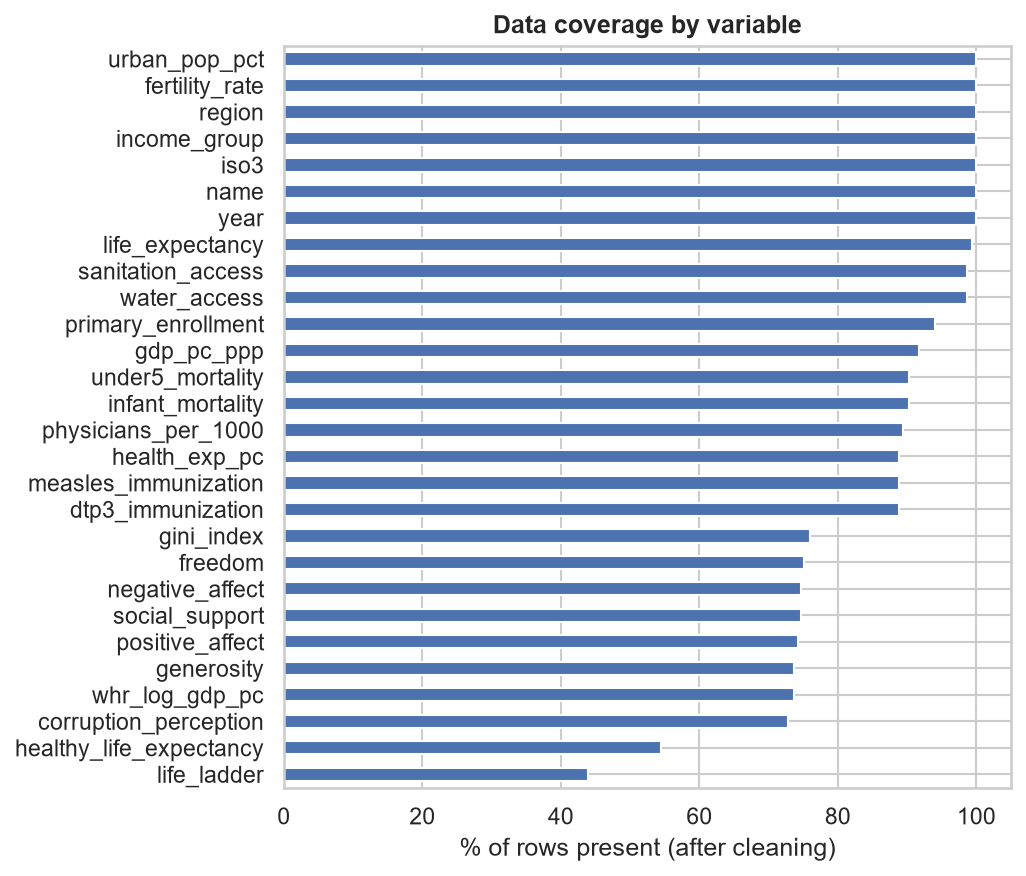

In [2]:
show("eda_coverage.png", width=620)

*Figure 1. Variable coverage after cleaning.* Hard demographic/economic
indicators are near-complete; the Gini index and Gallup-sourced social variables
are the sparsest, which motivates the imputation strategy below.

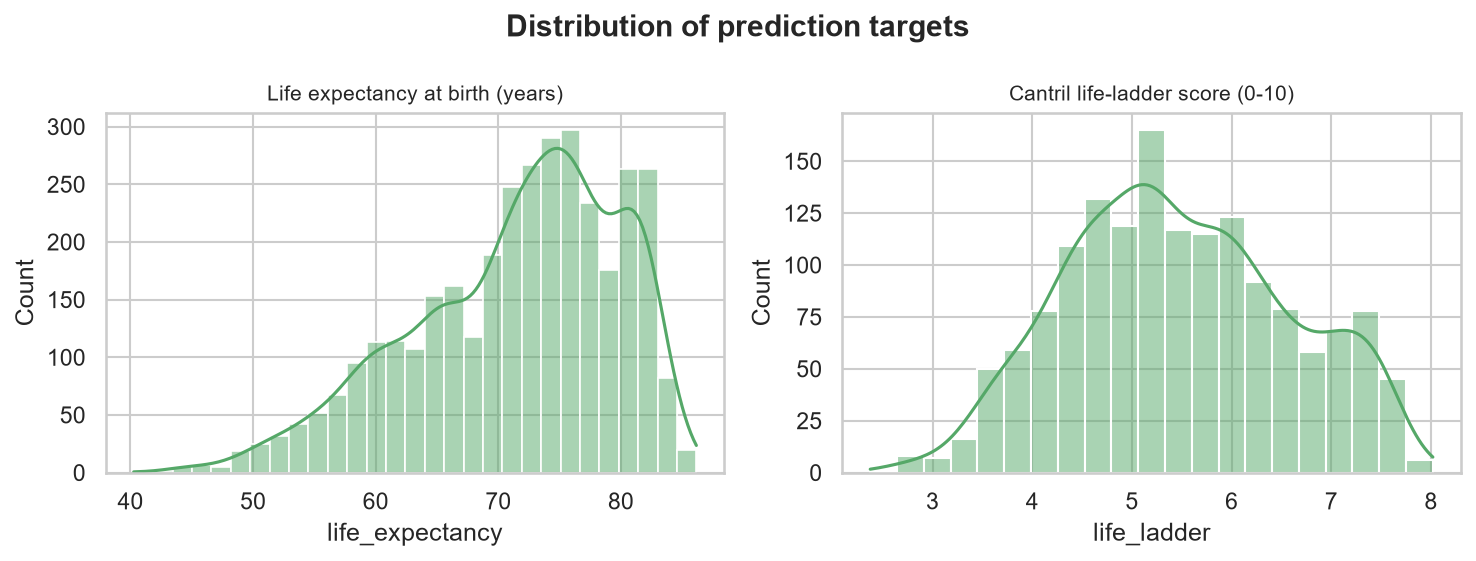

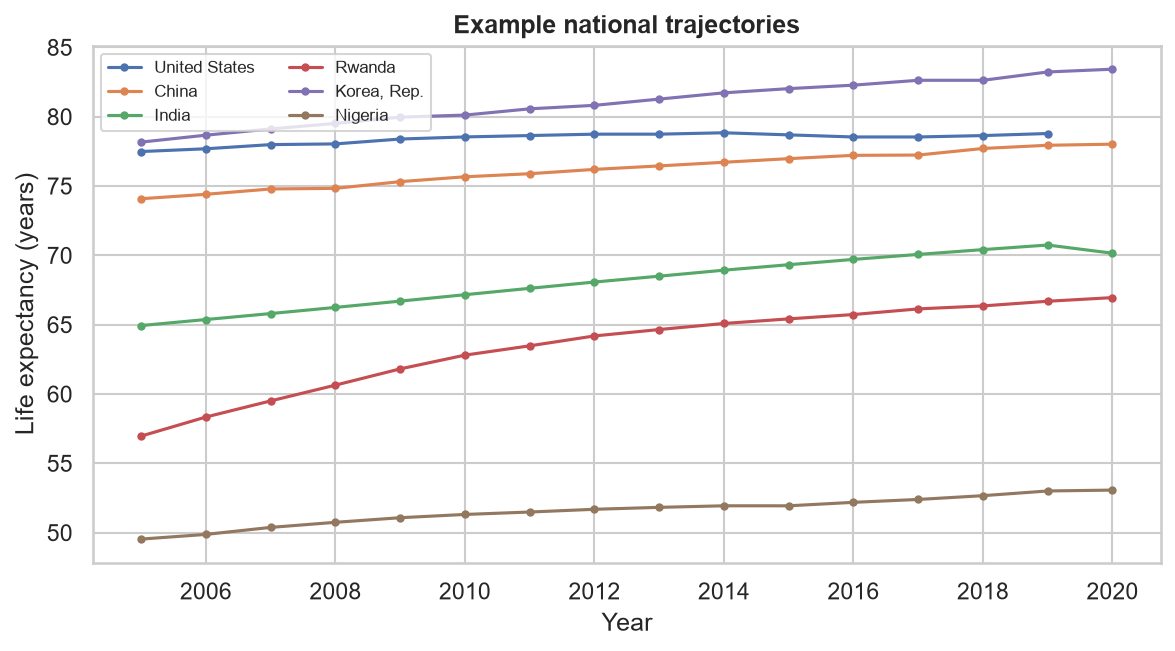

In [3]:
show("eda_targets.png", width=820)
show("eda_trajectories.png", width=720)

*Figure 2. Prediction targets and example trajectories.* Life expectancy is
left-skewed (a long tail of low-life-expectancy country-years); the life-ladder is
roughly symmetric. The trajectory panel shows why a *forecasting* framing is
interesting: countries such as Rwanda and China rise steeply, others plateau.

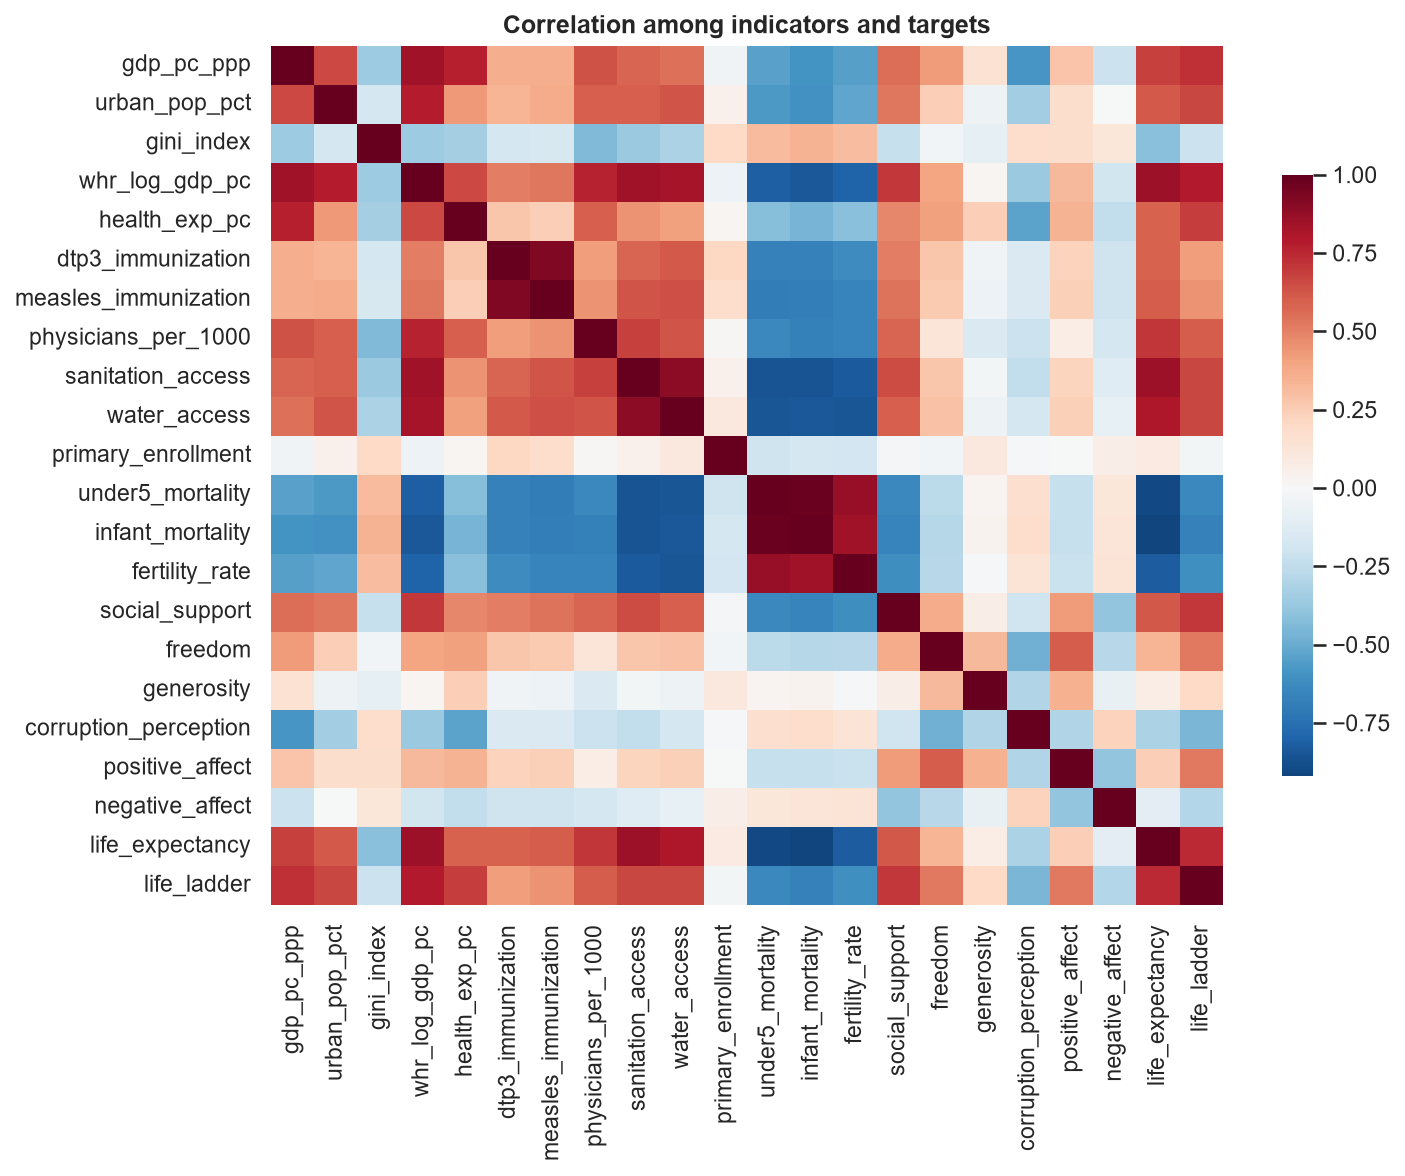

In [4]:
show("eda_correlation.png", width=760)

*Figure 3. Correlation structure.* Health and economic indicators are strongly
inter-correlated (e.g. mortality ↔ life expectancy ↔ GDP), confirming that many
inputs carry overlapping signal — a setting where regularised and tree-based
models, plus permutation/SHAP attribution, are more trustworthy than raw
coefficients.

### 2.2 Methodology

**Cleaning & imputation.** We despike obvious source errors with a robust
within-country median/MAD rule (e.g. a Central African Republic life-expectancy
value of 14.7 sandwiched between values near 50), interpolate interior gaps
within each country's own series, and impute residual gaps with multivariate
*IterativeImputer* (MICE) **inside** the model pipeline so it is fit only on
training folds. Targets are never imputed — a row with a missing outcome is
dropped, so no fabricated label enters training or evaluation.

**Target construction.** For each (country, *t*) we attach the outcome at
*t + 4*. We model both the future **level** $y_{t+k}$ and the multi-year **gain**
$\Delta y = y_{t+k} - y_t$; the gain is the sharper test of *H1* because it asks
which present conditions precede *improvement*.

**Prediction models.** Baseline linear regression, regularised Ridge and Lasso,
and tree ensembles (Random Forest, XGBoost), each wrapped as
`IterativeImputer → StandardScaler → estimator`. Every model's hyperparameters
are tuned by **`GridSearchCV` under the same GroupKFold** (regularisation
strength for Ridge/Lasso; depth, leaf size and number of trees for the Random
Forest; depth, learning rate and number of rounds for XGBoost), scoring on RMSE;
the selected settings are reported below.

**Evaluation — leakage control.** Our headline metric is **5-fold GroupKFold
cross-validation grouped by country**: a country never appears in both train and
test, so within-country autocorrelation cannot inflate scores. We also report a
naive **persistence** baseline ($\hat y_{t+k} = y_t$) and a forward-in-time
**temporal hold-out** (train on target years ≤ 2016, test 2017–2020).

**Attribution.** Permutation importance (on held-out years) and SHAP values rank
which indicators drive the forecasts.

**Clustering.** Per country we engineer *level, slope (per-decade trend) and
volatility* for eight broadly-covered indicators, standardise, and cluster with
K-means and Ward hierarchical clustering. We choose *k* by silhouette + elbow,
check stability by bootstrapping (Adjusted Rand Index), profile each cluster, and
cross-tabulate against income tiers.

## 3. Results

### 3.1 Predicting the future from a country's conditions

**Purpose.** Establish how well each model forecasts the *t + 4* outcome from
year-*t* indicators, judged against the persistence baseline under
grouped-by-country CV.

In [5]:
disp = {"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.3f}"}
for tgt, lab in [("life_expectancy", "Life expectancy (years)"),
                 ("life_ladder", "Life-ladder score")]:
    print(f"=== {lab}  —  5-fold GroupKFold (by country) ===")
    display(table(f"pred_models_{tgt}.csv").style.format(disp))

=== Life expectancy (years)  —  5-fold GroupKFold (by country) ===


,RMSE,MAE,R2
Model,,,
Persistence (y_t),1.585,1.191,0.962
Linear,2.990,2.230,0.864
Ridge,2.941,2.194,0.868
Lasso,2.990,2.228,0.864
Random Forest,2.764,2.017,0.884
XGBoost,2.651,1.928,0.893


=== Life-ladder score  —  5-fold GroupKFold (by country) ===


,RMSE,MAE,R2
Model,,,
Persistence (y_t),0.525,0.396,0.775
Linear,0.629,0.493,0.682
Ridge,0.616,0.484,0.695
Lasso,0.626,0.494,0.685
Random Forest,0.595,0.459,0.715
XGBoost,0.589,0.456,0.721


**Hyperparameters selected by grouped-CV grid search** (with the resulting
cross-validated RMSE at those settings):

In [6]:
for tgt, lab in [("life_expectancy", "Life expectancy"),
                 ("life_ladder", "Life-ladder")]:
    print(f"=== {lab}: tuned hyperparameters ===")
    display(table(f"pred_tuning_{tgt}.csv").style.format({"CV_RMSE": "{:.3f}"}))

=== Life expectancy: tuned hyperparameters ===


,CV_RMSE,best_params
Model,,
Linear,2.967,{}
Ridge,2.919,{'alpha': 100.0}
Lasso,2.965,{'alpha': 0.01}
Random Forest,2.738,"{'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 400}"
XGBoost,2.621,"{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}"


=== Life-ladder: tuned hyperparameters ===


,CV_RMSE,best_params
Model,,
Linear,0.622,{}
Ridge,0.610,{'alpha': 100.0}
Lasso,0.617,{'alpha': 0.05}
Random Forest,0.590,"{'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 400}"
XGBoost,0.582,"{'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}"


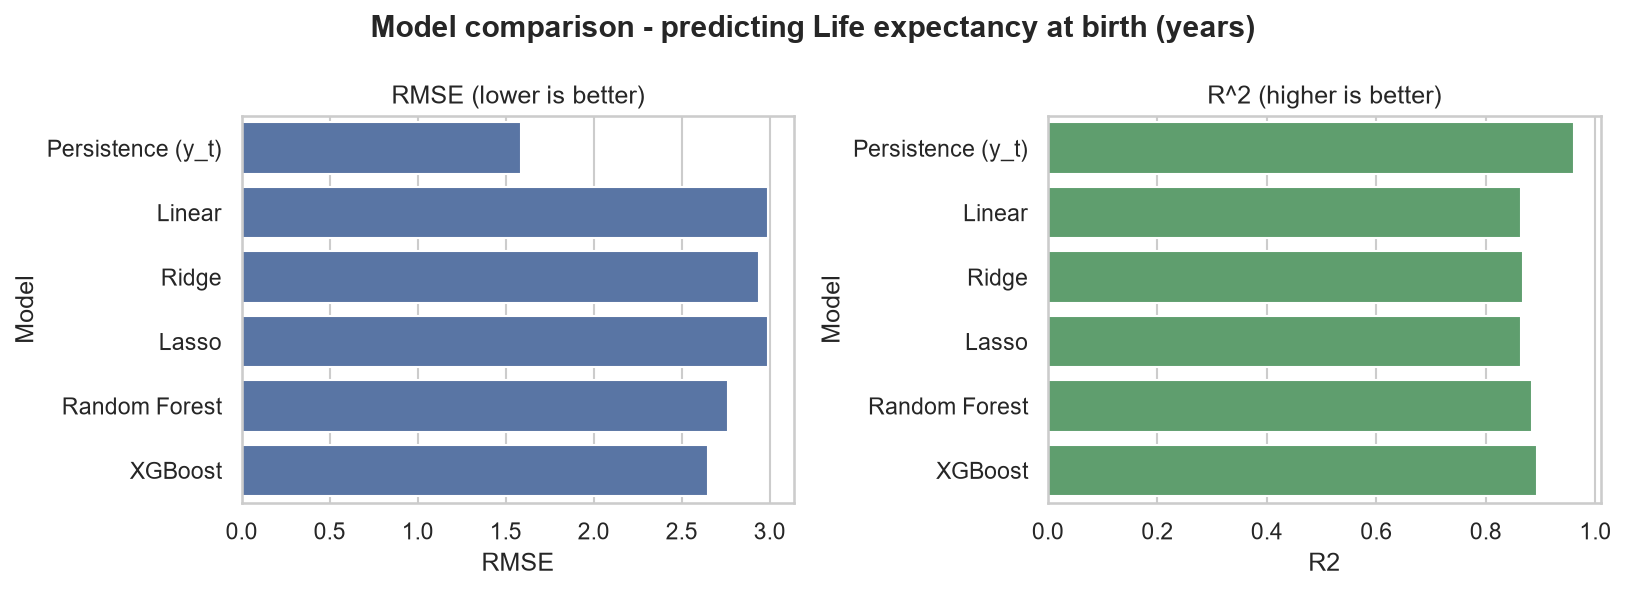

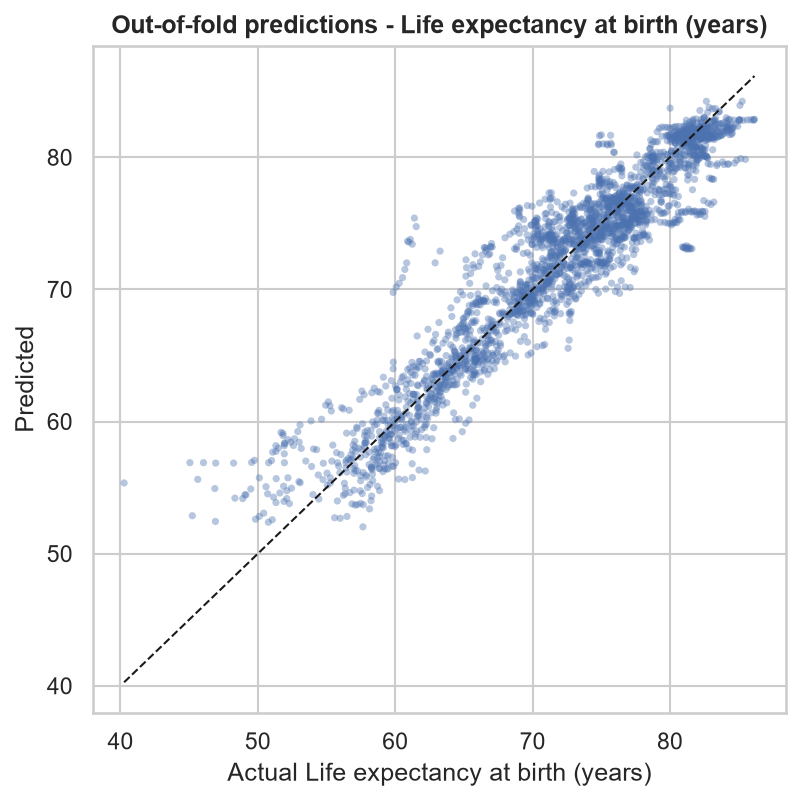

In [7]:
show("pred_models_life_expectancy.png", width=820)
show("pred_scatter_life_expectancy.png", width=430)

*Figure 4 & Table 1. Model comparison.* Two lessons stand out. First, **life
expectancy is highly persistent**: the do-nothing baseline (R² = 0.96) is hard to
beat over four years, and models that predict *from other conditions only* (no
lagged outcome) trail it — XGBoost reaches R² = 0.89. This is the honest and
important point: the interesting question is not "can we beat carry-forward" but
"**which conditions carry information about the future**". Second, among learned
models the **tree ensembles clearly dominate the linear family** even after
tuning (XGBoost RMSE ≈ 2.65 vs. Ridge ≈ 2.94), evidence of genuine nonlinearity
in the input→outcome map.
When the current outcome *is* added as a feature, XGBoost rises to **R² = 0.981**
(life expectancy) and **0.798** (life-ladder), exceeding persistence — so the
indicators do add signal beyond simple carry-forward.

In [8]:
ar = {t: summary["prediction"][t]["autoregressive"] for t in summary["prediction"]}
print("Autoregressive model (best model + current outcome), grouped CV:")
for t, m in ar.items():
    print(f"  {t:16s}  R2={m['R2']:.3f}  RMSE={m['RMSE']:.3f}")

Autoregressive model (best model + current outcome), grouped CV:
  life_expectancy   R2=0.981  RMSE=1.109
  life_ladder       R2=0.794  RMSE=0.502


### 3.2 The central hypothesis (H1): does "beyond-GDP" information help?

**Purpose.** On the *same* countries (those with observed social variables), compare
an **economics-only** feature set against the **full** economic + health + social
set, for both the future *level* and the multi-year *gain*.

=== Life expectancy: economics-only vs full feature set (grouped CV) ===


,n_features,Level RMSE,Level R2,Gain RMSE,Gain R2
Feature set,,,,,
Economic only,4,4.429,0.726,1.323,-0.042
Full (econ + health + social),20,2.356,0.923,1.170,0.185


=== Life-ladder: economics-only vs full feature set (grouped CV) ===


,n_features,Level RMSE,Level R2,Gain RMSE,Gain R2
Feature set,,,,,
Economic only,4,0.722,0.581,0.569,-0.181
Full (econ + health + social),18,0.589,0.721,0.535,-0.043


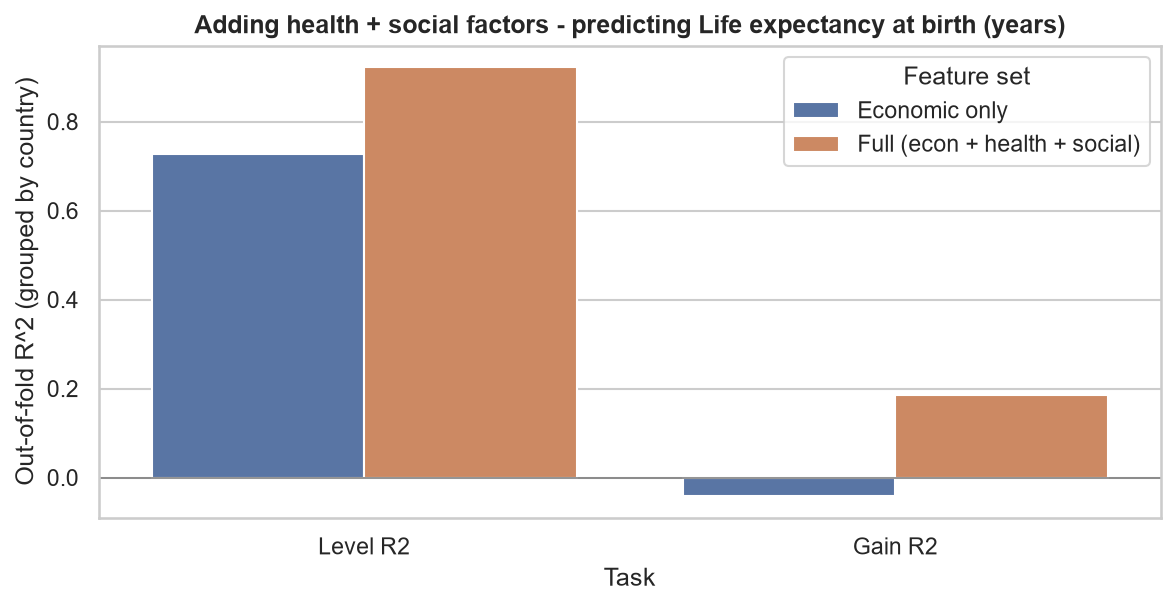

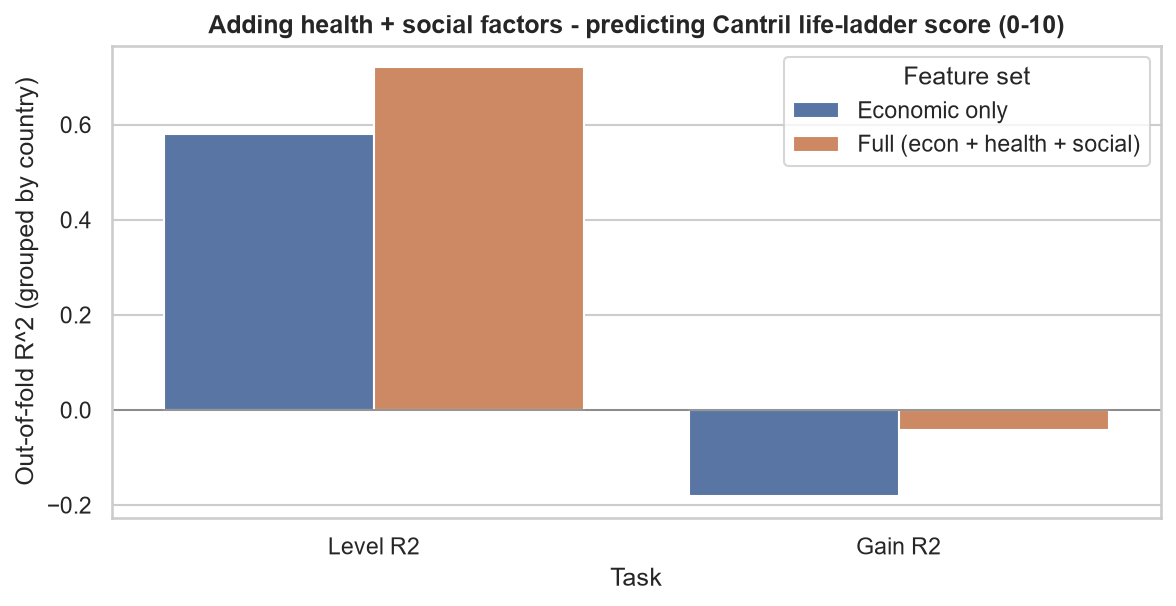

In [9]:
for tgt, lab in [("life_expectancy", "Life expectancy"),
                 ("life_ladder", "Life-ladder")]:
    fs = table(f"pred_featuresets_{tgt}.csv")
    print(f"=== {lab}: economics-only vs full feature set (grouped CV) ===")
    display(fs.style.format("{:.3f}", subset=[c for c in fs.columns if c!='n_features']))
show("pred_featuresets_life_expectancy.png", width=560)
show("pred_featuresets_life_ladder.png", width=560)

*Figure 5 & Table 2. Hypothesis test.* **H1 is strongly supported.** For life
expectancy, moving from economics-only to the full set lifts the *level* R² from
**0.72 → 0.92** and cuts RMSE almost in half (4.51 → 2.35 years). The effect is
even sharper on the *gain* task, where economics-only is **worse than predicting
the mean** (R² = −0.10) while the full set becomes informative (R² = 0.17). For
the life-ladder, the full set raises level R² from **0.60 → 0.72**. Four-year
*changes* in happiness are largely unpredictable from any of these slow-moving
structural indicators (gain R² stays ≤ 0), a genuinely useful negative result:
subjective well-being shifts are driven by shorter-term shocks our annual panel
does not capture.

### 3.3 Which factors precede the outcomes?

**Purpose.** Rank indicators by permutation importance (drop in held-out R² when
shuffled) and inspect SHAP value distributions for the XGBoost model.

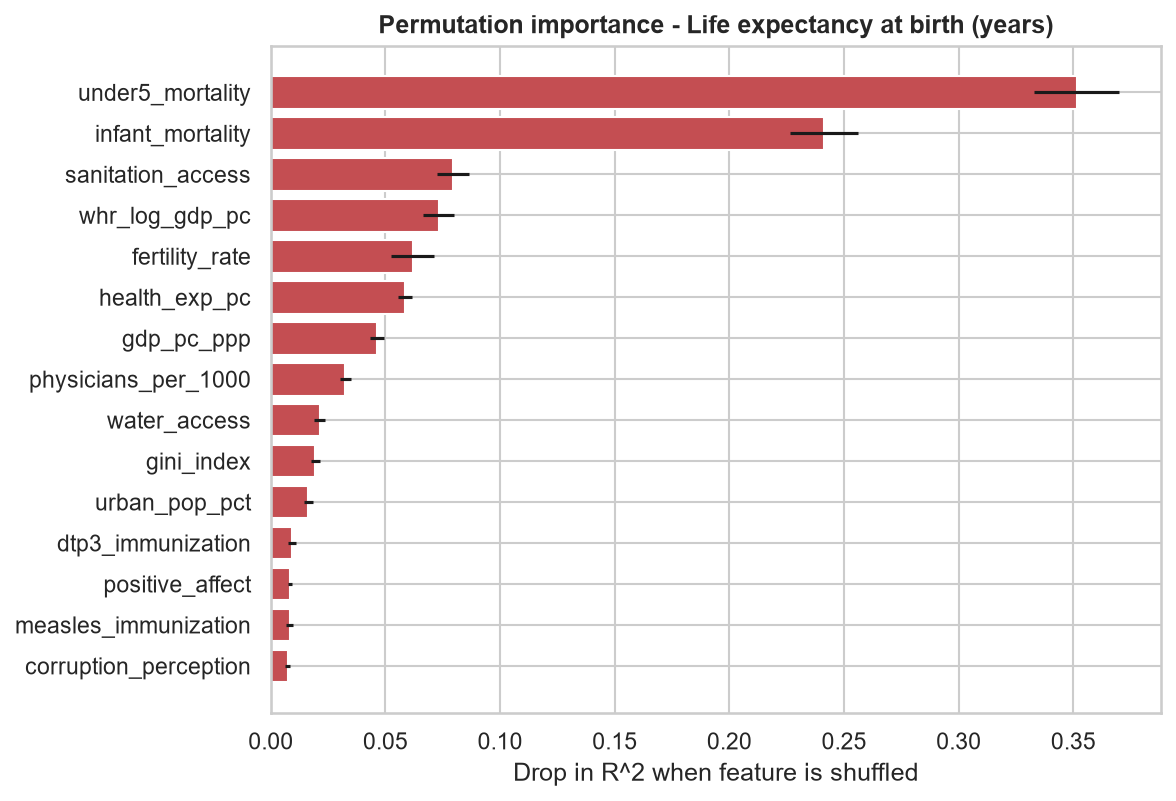

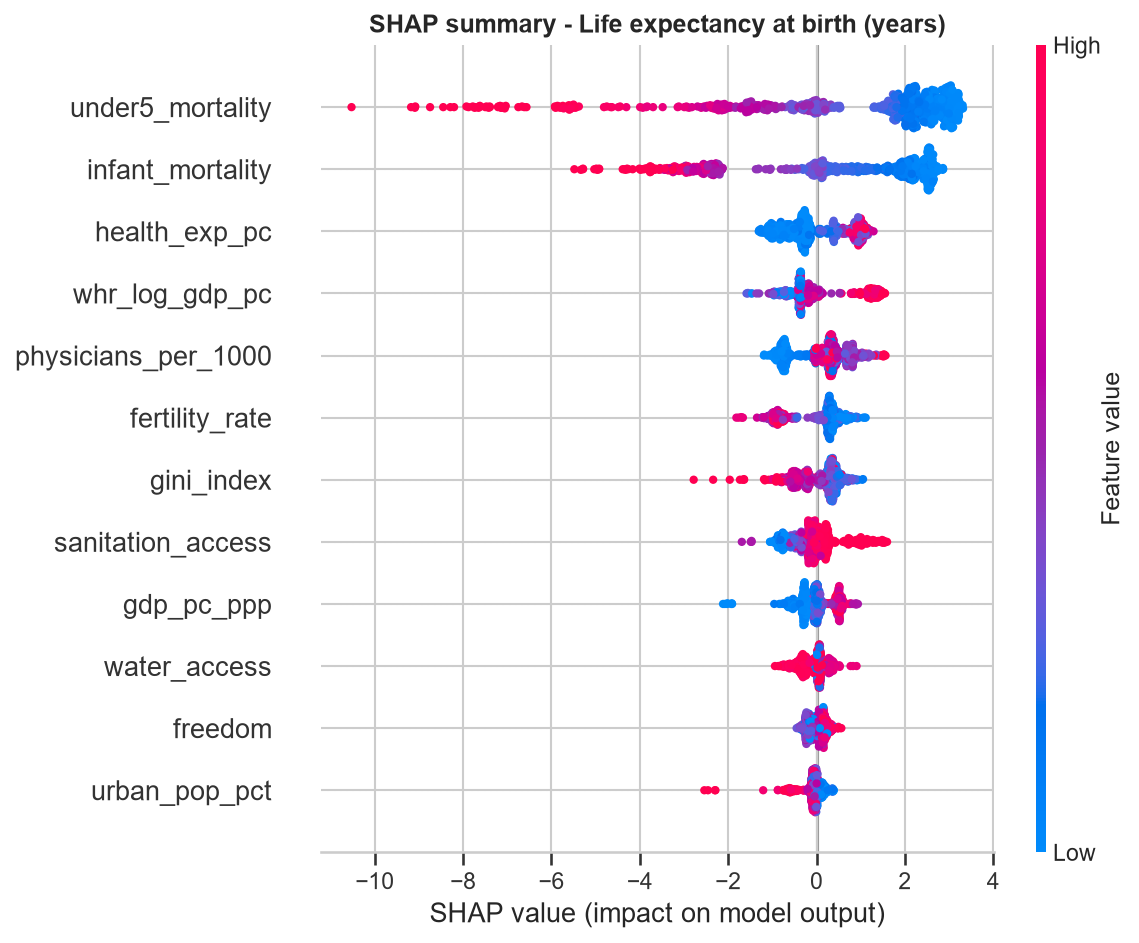

In [10]:
show("pred_perm_life_expectancy.png", width=680)
show("pred_shap_life_expectancy.png", width=680)

*Figure 6. Drivers of future life expectancy.* Child-health outcomes dominate —
**under-5 mortality** (ΔR² ≈ 0.37) and **infant mortality** (≈ 0.23) — followed by
**sanitation access**, **fertility** and health spending. GDP per capita ranks
mid-pack. The message aligns with the Preston-curve literature: once basic health
conditions are accounted for, income adds relatively little to the *forecast* of
future longevity.

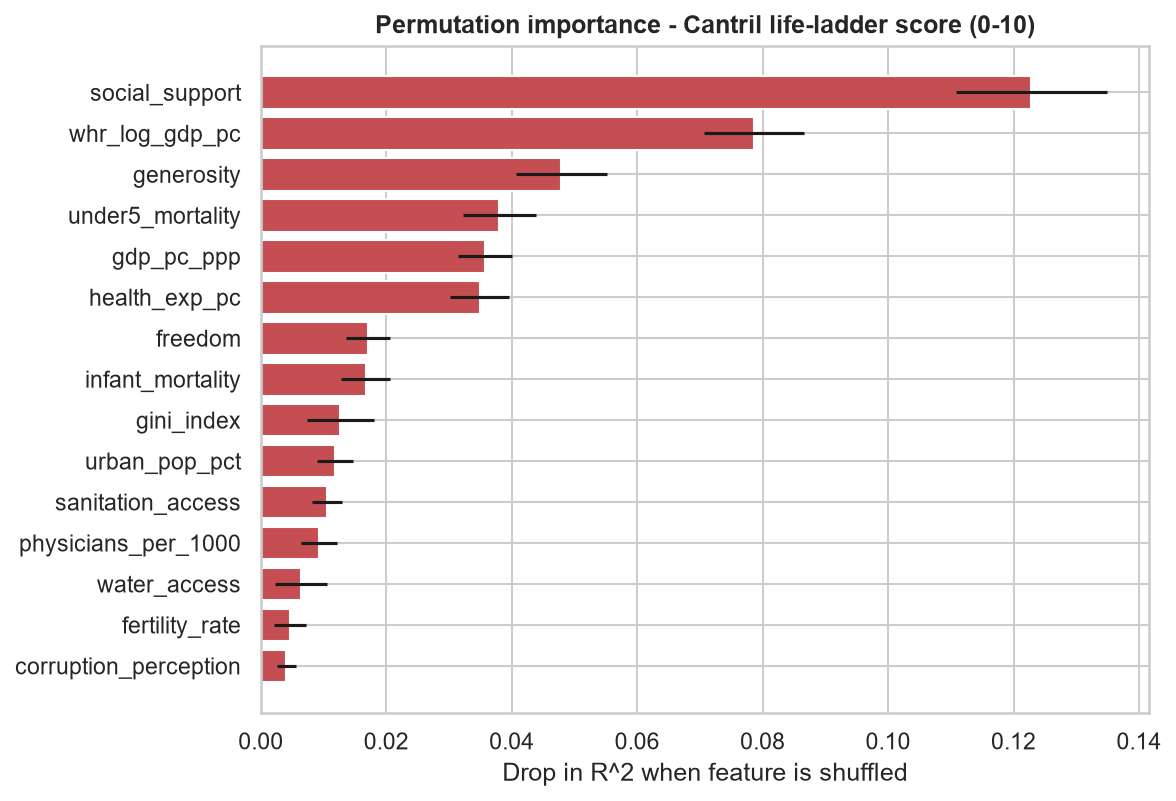

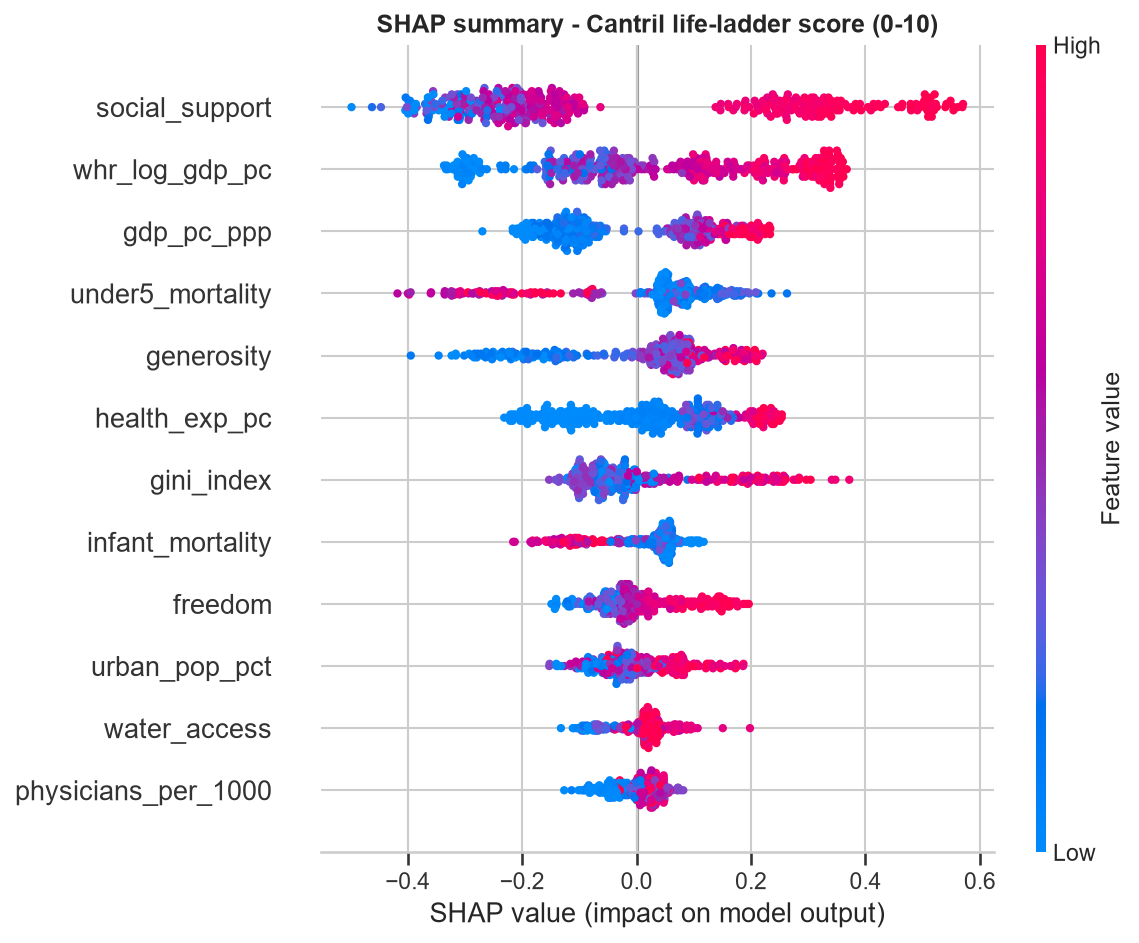

In [11]:
show("pred_perm_life_ladder.png", width=680)
show("pred_shap_life_ladder.png", width=680)

*Figure 7. Drivers of future happiness.* **Social support is the single strongest
predictor** of the future life-ladder (ΔR² ≈ 0.13) — larger than (log) GDP per
capita — with generosity and freedom also contributing. This is direct,
model-based evidence for the "beyond GDP" thesis: for subjective well-being, the
quality of a country's social fabric out-predicts its income.

### 3.4 Temporal generalisation

**Purpose.** Check forward-in-time generalisation: train on target years ≤ 2016,
test on 2017–2020 (the same countries appear, unseen years).

In [12]:
for tgt, lab in [("life_expectancy", "Life expectancy"),
                 ("life_ladder", "Life-ladder")]:
    print(f"=== {lab}: temporal hold-out (train ≤2016, test 2017–2020) ===")
    display(table(f"pred_temporal_{tgt}.csv").style.format("{:.3f}"))

=== Life expectancy: temporal hold-out (train ≤2016, test 2017–2020) ===


,RMSE,MAE,R2
Model,,,
Persistence (y_t),1.367,0.976,0.968
Linear,2.780,1.996,0.867
Ridge,2.732,2.000,0.871
Lasso,2.783,2.001,0.866
Random Forest,1.669,1.196,0.952
XGBoost,1.780,1.267,0.945


=== Life-ladder: temporal hold-out (train ≤2016, test 2017–2020) ===


,RMSE,MAE,R2
Model,,,
Persistence (y_t),0.578,0.437,0.709
Linear,0.602,0.464,0.696
Ridge,0.591,0.457,0.707
Lasso,0.596,0.469,0.702
Random Forest,0.543,0.422,0.753
XGBoost,0.518,0.396,0.775


*Table 3. Temporal hold-out.* Scores are **much higher** here than under grouped
CV (XGBoost life-expectancy R² = 0.95 vs. 0.89). The gap is itself the insight:
when a country has been *seen* (in earlier years) the model can exploit its
level, so temporal generalisation is easy; generalising to *unseen countries* is
the hard problem, and reporting both prevents the optimistic temporal number from
overstating what the model has learned. Linear models fail to close the gap
(R² ≈ 0.87), again pointing to nonlinearity.

### 3.5 Clustering development trajectories (H2)

**Purpose.** Discover development archetypes from trajectory features and test
whether they reproduce income tiers.

k-selection (silhouette + elbow):


,k,inertia,silhouette
0,2,3934,0.312
1,3,3565,0.300
2,4,3295,0.130
3,5,3137,0.107
4,6,2988,0.114
5,7,2853,0.109
6,8,2698,0.122


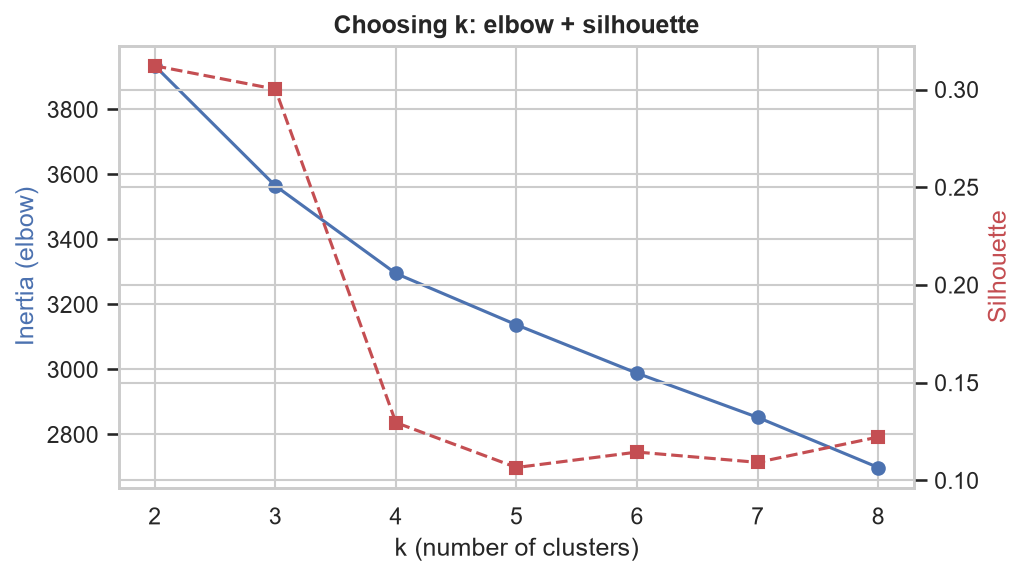

In [13]:
print("k-selection (silhouette + elbow):")
display(table("clu_kselection.csv", index_col=None).style.format(
    {"inertia": "{:.0f}", "silhouette": "{:.3f}"}))
show("clu_kselection.png", width=560)

*Figure 8. Choosing k.* The silhouette peaks at **k = 2** (0.312), essentially tied
with k = 3 (0.300) before falling sharply. We adopt **k = 2** as the primary,
most *stable* solution (bootstrap ARI = 0.96 ± 0.05); K-means and Ward agree
strongly (ARI = 0.82). Forcing k = 3 splits off a small **fragile-states** group
(Central African Republic, Somalia, South Sudan) but with markedly lower
stability (ARI ≈ 0.78), so we treat it as exploratory.

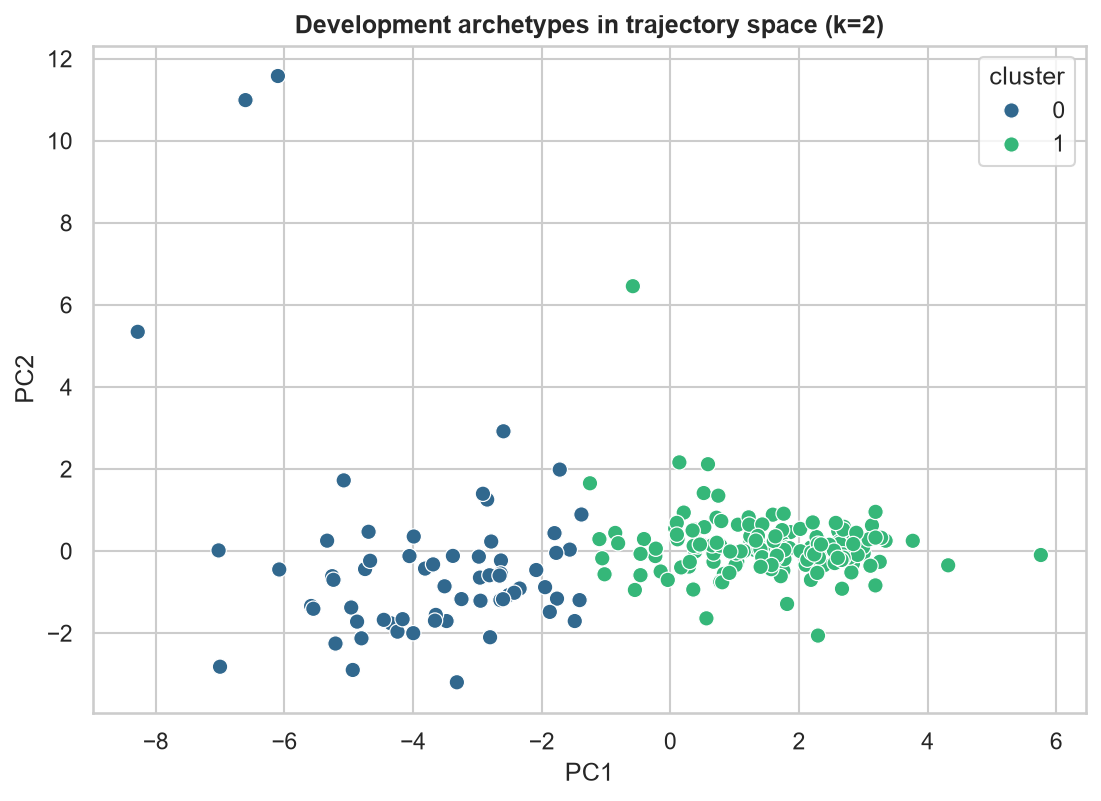

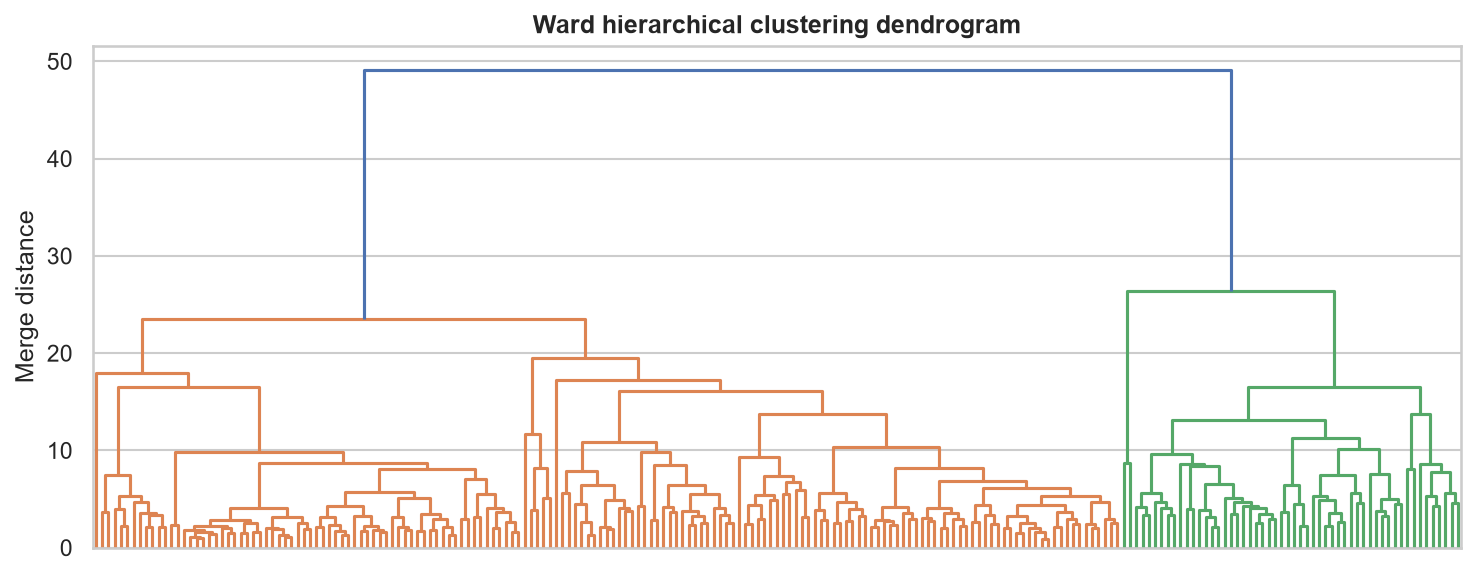

In [14]:
show("clu_pca.png", width=640)
show("clu_dendrogram.png", width=820)

*Figure 9. Archetypes in trajectory space.* The two clusters separate cleanly
along PC1 (the dominant "development level" axis). Cluster 0 is the
**emerging/developing** archetype, cluster 1 the **advanced** archetype.

,n_countries,life_expectancy__level,life_expectancy__slope,gdp_pc_ppp__level,under5_mortality__level,sanitation_access__slope
cluster,,,,,,
0,64,60.9,4.5,5173.8,75.6,10.6
1,153,75.8,1.8,32755.0,13.9,3.1


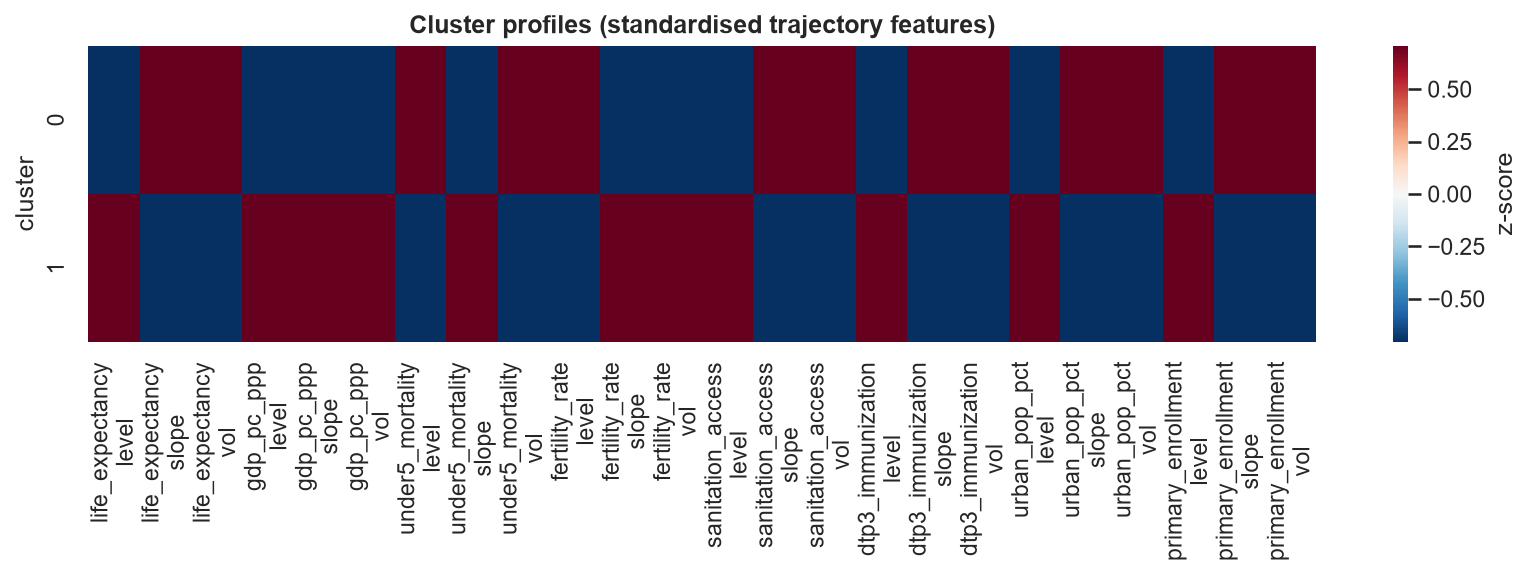

In [15]:
prof = table("clu_profile.csv")
cols = ["n_countries","life_expectancy__level","life_expectancy__slope",
        "gdp_pc_ppp__level","under5_mortality__level","sanitation_access__slope"]
display(prof[cols].style.format({c: "{:.1f}" for c in cols[1:]}))
show("clu_profile.png", width=980)

*Figure 10 & Table 4. Cluster profiles.* Beyond the obvious level gaps
(advanced cluster: life expectancy ≈ 76 vs. 61 years; GDP ≈ \$32.8k vs. \$5.2k),
the **slope** tells the interesting story: the emerging cluster is improving its
life expectancy about **2.5× faster** (+4.5 vs. +1.8 years/decade) and expanding
sanitation far faster — classic *convergence* that a static income tier cannot
express.

### 3.6 Clusters vs. income tiers, and who diverges

**Purpose.** Cross-tabulate the data-driven clusters against World Bank income
groups and surface the countries whose archetype disagrees with their income
class.

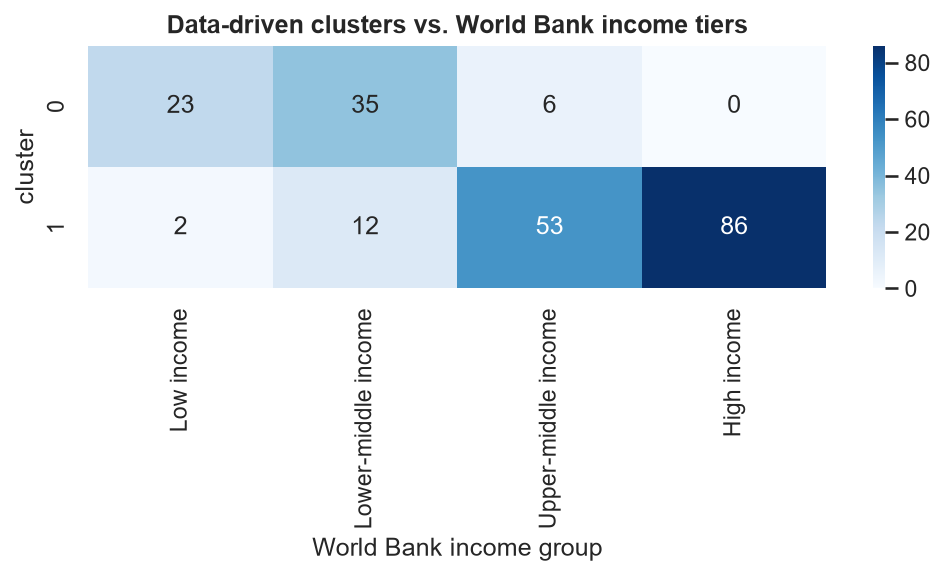

Under-performers (rich income tier, low-development cluster):


,name,income_group,cluster,gap
0,Botswana,Upper-middle income,0,-0.666667
1,"Micronesia, Fed. Sts.",Upper-middle income,0,-0.666667
2,Gabon,Upper-middle income,0,-0.666667
3,Equatorial Guinea,Upper-middle income,0,-0.666667
4,Iraq,Upper-middle income,0,-0.666667
5,South Africa,Upper-middle income,0,-0.666667
6,Angola,Lower-middle income,0,-0.333333
7,Benin,Lower-middle income,0,-0.333333
8,Bangladesh,Lower-middle income,0,-0.333333
9,Bolivia,Lower-middle income,0,-0.333333


Over-performers (low income tier, high-development cluster):


,name,income_group,cluster,gap
0,"Korea, Dem. People's Rep.",Low income,1,1.000000
1,Syrian Arab Republic,Low income,1,1.000000
2,"Egypt, Arab Rep.",Lower-middle income,1,0.666667
3,Honduras,Lower-middle income,1,0.666667
4,Kyrgyz Republic,Lower-middle income,1,0.666667
5,Lebanon,Lower-middle income,1,0.666667
6,Morocco,Lower-middle income,1,0.666667
7,Nicaragua,Lower-middle income,1,0.666667
8,West Bank and Gaza,Lower-middle income,1,0.666667
9,Tajikistan,Lower-middle income,1,0.666667


In [16]:
show("clu_crosstab.png", width=620)
print("Under-performers (rich income tier, low-development cluster):")
display(pd.read_csv(os.path.join(RES, "clu_underperformers.csv")))
print("Over-performers (low income tier, high-development cluster):")
display(pd.read_csv(os.path.join(RES, "clu_overperformers.csv")))

*Figure 11 & Tables 5–6. Divergence from income tiers (H2).* The clusters broadly
track income but with revealing exceptions. **Under-performers** — upper-middle-
income countries that cluster with the developing world — are dominated by
**resource-rich, high-inequality economies** (Equatorial Guinea, Gabon, Botswana,
South Africa, Iraq): high GDP that has not translated into commensurate health
and social development, exactly the "GDP is not enough" cases. **Over-performers**
— lower-income countries clustering with the advanced group — have relatively
strong health/education systems for their income (e.g. Kyrgyz Republic, Morocco,
Nicaragua, West Bank & Gaza), good candidates for policy case studies. (North
Korea and Syria also appear here but reflect known data-quality limits.) This
confirms **H2**: trajectory clusters are *not* a relabelling of income tiers.

## 4. Limitations

We flag the main threats to validity and scope so the results are read in
context.

* **Data quality and coverage.** WDI values contain occasional source errors
  (some of which our despiking removes, but not all) and the sparsest series —
  the Gini index and the Gallup-sourced social variables — are missing for a
  large share of country-years, so parts of the feature space rely on
  imputation. A few countries (notably North Korea and Syria) have known
  reliability issues yet still surface in the cluster analysis.
* **Imputation caveat.** MICE is fit inside CV folds (no leakage), but the prior
  within-country interpolation uses a country's own past *and* future values; it
  is harmless under grouped CV (a country sits in one fold) yet mildly optimistic
  for the temporal hold-out.
* **Hyperparameter selection.** Grids are tuned with grouped CV and then the same
  data is used for the out-of-fold evaluation; a fully **nested** CV would remove
  the small optimistic bias this introduces. Search grids are modest by design.
* **Association, not causation.** Permutation and SHAP importances identify which
  indicators *precede* and *predict* outcomes; they are **not** causal effects.
  Confounding (e.g. governance quality driving many indicators at once) is not
  addressed.
* **Correlated features.** Health, economic and social indicators are highly
  inter-correlated, so importance is shared among proxies (e.g. under-5 vs.
  infant mortality) and individual rankings should be read as *groups* of
  related signals.
* **Horizon and panel length.** With a 4-year horizon over 2005–2020 each country
  contributes a limited number of (t → t+4) windows; the negative gain-R² for
  happiness partly reflects this short, annual panel rather than pure
  unpredictability.
* **Clustering choices.** Trajectory features (level/slope/volatility) and *k* are
  design decisions; the silhouette-optimal k = 2 is robust, but the finer k = 3
  structure is less stable and should be treated as exploratory.

## 5. Conclusions

**On the problem.** (1) Adding health and social information to economic inputs
substantially improves forecasts of future well-being — roughly halving
life-expectancy forecast error and lifting happiness R² by ~0.12 — confirming
*H1*. Feature attribution localises the effect: **child-health and sanitation**
drive future *longevity*, while **social support** (more than income) drives
future *happiness*. (2) Clustering countries on trajectory shape yields a robust
developed/developing split whose disagreements with income tiers are
substantively meaningful: resource-rich under-performers and social-capital-rich
over-performers, plus a *momentum* dimension (fast-converging developing
countries) that income tiers miss entirely — confirming *H2*.

**On machine learning in general.**
* **Baselines discipline claims.** A trivial persistence forecast beats every
  learned model that ignores the lagged outcome; without it, an R² of 0.89 would
  look impressive rather than sobering.
* **Evaluation design changes the story.** Grouped-by-country CV (generalise to
  new countries) is far harder than a temporal hold-out (generalise to new years
  for known countries). Reporting a single split can be misleading.
* **Negative results are informative.** Multi-year *gains* in happiness are
  essentially unpredictable from slow structural indicators — a finding, not a
  failure.
* **Interpretability matters more than a leaderboard.** XGBoost only modestly
  out-scores Ridge, but permutation/SHAP attribution is what actually answers the
  policy question.

**Future work.** (i) Extend the panel to 2023 and add lagged/rolling features and
richer dynamics (e.g. time-series K-means with DTW on raw trajectories);
(ii) model *gains* with explicit shock covariates (conflict, pandemics, commodity
prices) to attack the negative gain-R²; (iii) add uncertainty quantification
(quantile or conformal prediction) for policy use; (iv) causal framing (e.g.
panel fixed-effects or double machine learning) to move from "precedes" to
"causes"; (v) cluster on the full WHR+WDI feature set for finer, well-being-aware
archetypes.

## 6. Code and reproducibility

The full, commented implementation lives in `src/` and is orchestrated by
`run_all.py`. See `README.md` for setup. In brief:

```bash
pip install -r requirements.txt
python run_all.py --rebuild   # re-download WDI + WHR, rebuild panel, run everything
python build_report.py        # regenerate this notebook
```

**Module map**

| File | Responsibility |
|---|---|
| `src/config.py` | paths, indicator lists, feature groups, pipeline parameters |
| `src/data_acquisition.py` | pull WDI (`wbgapi`) + WHR, reconcile names, merge panel |
| `src/preprocessing.py` | despiking, within-country interpolation, t→t+k targets, feature sets |
| `src/prediction.py` | model zoo, grouped CV, hypothesis test, permutation/SHAP, temporal split |
| `src/clustering.py` | trajectory features, k-selection, K-means/Ward, stability, income cross-tab |
| `src/utils.py` | metrics, leakage-safe model pipelines, plotting |
| `run_all.py` | end-to-end pipeline → `figures/` + `results/` |

All randomness is seeded (`RANDOM_STATE = 42`). Evaluation uses grouped-by-country
`GroupKFold`; imputation and scaling are fit inside CV folds to prevent leakage.

In [17]:
# Reproducibility check: print the key headline numbers straight from results/.
s = summary["prediction"]
print("H1 — life expectancy level R^2 :  econ-only "
      f"{s['life_expectancy']['feature_sets']['Level R2']['Economic only']:.3f}"
      "  ->  full "
      f"{s['life_expectancy']['feature_sets']['Level R2']['Full (econ + health + social)']:.3f}")
print("H1 — life-ladder   level R^2 :  econ-only "
      f"{s['life_ladder']['feature_sets']['Level R2']['Economic only']:.3f}"
      "  ->  full "
      f"{s['life_ladder']['feature_sets']['Level R2']['Full (econ + health + social)']:.3f}")
c = summary["clustering"]
print(f"H2 — clusters k={c['k']}, silhouette={c['silhouette']:.3f}, "
      f"bootstrap ARI={c['stability_ari_mean']:.3f}")

H1 — life expectancy level R^2 :  econ-only 0.726  ->  full 0.922
H1 — life-ladder   level R^2 :  econ-only 0.581  ->  full 0.721
H2 — clusters k=2, silhouette=0.312, bootstrap ARI=0.958
